In [ ]:
# %load_ext autoreload
# %autoreload 2

In [14]:
import os
import sys

sys.path.append(os.path.expanduser('~/Code/wmh-mc-seg'))  # For VSCode

from src.datamodules import WMHDataModule

# matplotlib.rcParams['text.usetex'] = True

from notebooks.utils.metrics_utils import *

In [15]:
data_root = os.path.expanduser('~/Code/datasets/wmh/')
centers_train = ['UtAmSi']
centers_test = ['Utrecht', 'Amsterdam', 'Singapore', 'UMCL']
group_test = {'UtAmSi': ['Utrecht', 'Amsterdam', 'Singapore']}  # Group for plot
rename_centers = {'UtAmSi': 'In-distribution', 'UMCL': 'Out-of-distribution'}

losses = ['CE', 'CE_MEEP', 'CE_KL', 'CE_MEALL']
runs_to_compare = {
    'CE UtAmSi': 'training_Utrecht_Amsterdam_Singapore_CE_3684_best',
    'CE_MEALL UtAmSi': 'training_Utrecht_Amsterdam_Singapore_MEALL_8766_best',
    'CE_MEEP UtAmSi': 'training_Utrecht_Amsterdam_Singapore_MEEP_6996_best',
    'CE_KL UtAmSi': 'training_Utrecht_Amsterdam_Singapore_cekl_4187_best',
}

In [16]:
test_splits = {}
for center in ['Utrecht', 'Amsterdam', 'Singapore']:
    dm = WMHDataModule(data_root, 1, f'training:{center}', [.7, .1, .2],
                       seed=42)
    _, _, ts_spl = dm.generate_splits()
    test_splits[center] = ts_spl

test_splits['UMCL'] = WMHDataModule(
    data_root, 1, 'training:UMCL', [0, 0, 1]).generate_splits()[2]

In [17]:
for key, val in group_test.items():  # Group test datasets if needed
    test_splits[key] = []
    for center in val:
        test_splits[key] += test_splits[center]
        del test_splits[center]
        # Remove center from centers_test
        centers_test.remove(center)
    centers_test.append(key)

In [18]:
plot_data = {
    'centers_train': centers_train,
    'runs_to_compare': runs_to_compare,
    'centers_test': centers_test,
    'test_splits': test_splits,
    'losses': losses,
}


In [19]:
# Compute entropy images
for tr_center in centers_train:
    for loss in losses:
        run_name = runs_to_compare.get(f'{loss} {tr_center}')
        if run_name is None:
            print(f'No run for {loss} {tr_center}.')
            continue

        for ts_center in centers_test:
            gt_paths = get_gt_paths(test_splits[ts_center])
            for subj_path in gt_paths:
                pred_softmax_path = os.path.join(subj_path,
                                                 f'pred_wmh_softmax_{run_name}.nii.gz')
                pred_softmax = nib.load(pred_softmax_path).get_fdata()

                entropy_img = entropy(pred_softmax[:, :, :, 1],
                                      apply_mean=False)
                # save the img with the same metadata as the pred_softmax
                entropy_img_path = os.path.join(subj_path,
                                                f'entropy_{run_name}.nii.gz')
                nib.save(nib.Nifti1Image(entropy_img,
                                         nib.load(pred_softmax_path).affine),
                         entropy_img_path)
                print(
                    f'Saved entropy image for {run_name} at {entropy_img_path}')

Saved entropy image for training_Utrecht_Amsterdam_Singapore_CE_3684_best at /home/appuser/Code/datasets/wmh/training/UMCL/20/entropy_training_Utrecht_Amsterdam_Singapore_CE_3684_best.nii.gz
Saved entropy image for training_Utrecht_Amsterdam_Singapore_CE_3684_best at /home/appuser/Code/datasets/wmh/training/UMCL/15/entropy_training_Utrecht_Amsterdam_Singapore_CE_3684_best.nii.gz
Saved entropy image for training_Utrecht_Amsterdam_Singapore_CE_3684_best at /home/appuser/Code/datasets/wmh/training/UMCL/11/entropy_training_Utrecht_Amsterdam_Singapore_CE_3684_best.nii.gz
Saved entropy image for training_Utrecht_Amsterdam_Singapore_CE_3684_best at /home/appuser/Code/datasets/wmh/training/UMCL/27/entropy_training_Utrecht_Amsterdam_Singapore_CE_3684_best.nii.gz
Saved entropy image for training_Utrecht_Amsterdam_Singapore_CE_3684_best at /home/appuser/Code/datasets/wmh/training/UMCL/23/entropy_training_Utrecht_Amsterdam_Singapore_CE_3684_best.nii.gz


KeyboardInterrupt: 

In [20]:
subjs = [pths for pths in test_splits.values()]

/tmp/ipykernel_13/3055586488.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


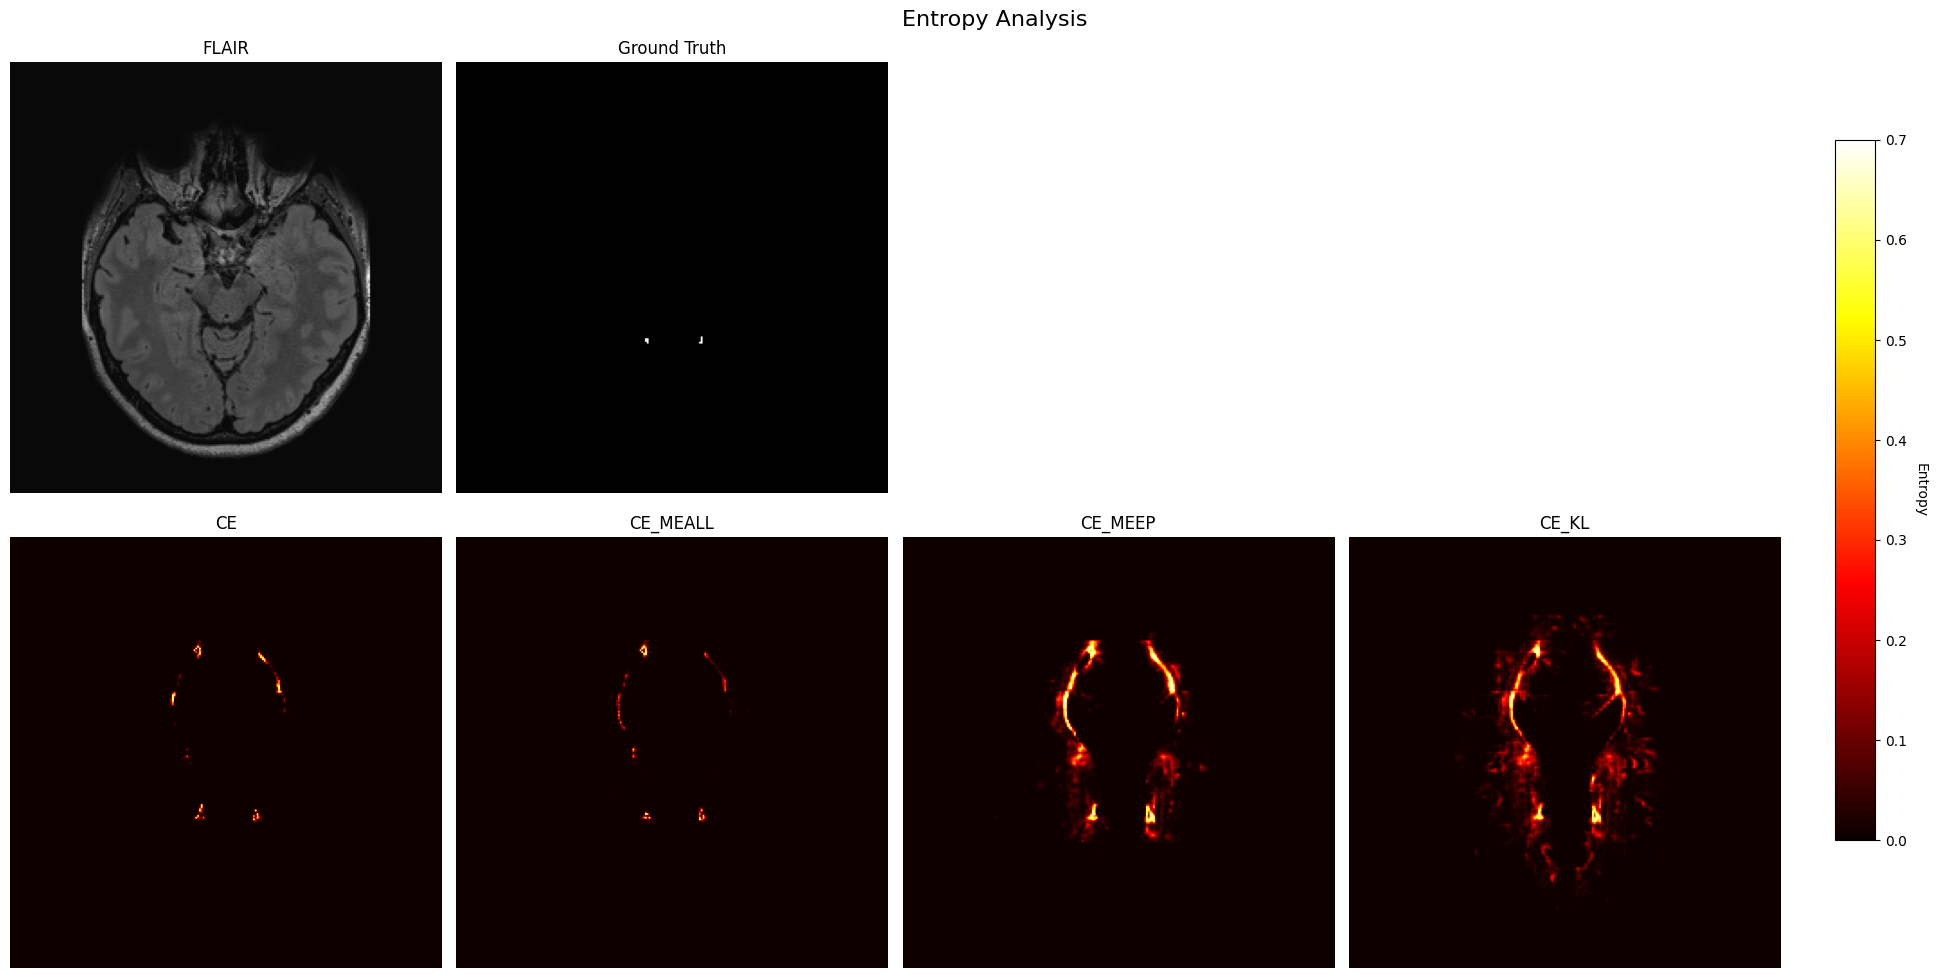

In [21]:
# Plot with image examples
def display_example(subject):
    # Load images
    flair_path = os.path.expanduser(os.path.join(subject, 'pre/FLAIR.nii.gz'))
    gt_path = os.path.expanduser(os.path.join(subject, 'wmh.nii.gz'))
    entropy_ce_path = os.path.expanduser(os.path.join(subject,
                                                      'entropy_training_Utrecht_Amsterdam_Singapore_CE_3684_best.nii.gz'))
    entropy_ce_meall_path = os.path.expanduser(os.path.join(subject,
                                                            'entropy_training_Utrecht_Amsterdam_Singapore_MEALL_8766_best.nii.gz'))
    entropy_ce_meep_path = os.path.expanduser(os.path.join(subject,
                                                           'entropy_training_Utrecht_Amsterdam_Singapore_MEEP_6996_best.nii.gz'))
    entropy_ce_kl_path = os.path.expanduser(os.path.join(subject,
                                                         'entropy_training_Utrecht_Amsterdam_Singapore_cekl_4187_best.nii.gz'))

    imgs = {
        'FLAIR': nib.load(flair_path).get_fdata(),
        'GT': nib.load(gt_path).get_fdata(),
        'CE': nib.load(entropy_ce_path).get_fdata(),
        'CE_MEALL': nib.load(entropy_ce_meall_path).get_fdata(),
        'CE_MEEP': nib.load(entropy_ce_meep_path).get_fdata(),
        'CE_KL': nib.load(entropy_ce_kl_path).get_fdata(),
    }

    # Get middle slice
    slice_no = imgs['FLAIR'].shape[2] // 2

    # Rotate images 90 degrees
    for key in imgs:
        imgs[key] = np.rot90(imgs[key][:, :, slice_no])

    # Set up the plot
    fig, axs = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle('Entropy Analysis', fontsize=16)

    # Plot FLAIR and GT
    axs[0, 0].imshow(imgs['FLAIR'], cmap='gray')
    axs[0, 0].set_title('FLAIR')
    axs[0, 0].axis('off')

    axs[0, 1].imshow(imgs['GT'], cmap='gray')
    axs[0, 1].set_title('Ground Truth')
    axs[0, 1].axis('off')

    # Remove unused subplots in the top row
    for ax in axs[0, 2:]:
        ax.remove()

    # Plot entropy images
    vmin, vmax = 0, 0.7
    cmap = 'hot'

    entropy_imgs = ['CE', 'CE_MEALL', 'CE_MEEP', 'CE_KL']
    for i, key in enumerate(entropy_imgs):
        im = axs[1, i].imshow(imgs[key], cmap=cmap, vmin=vmin, vmax=vmax)
        axs[1, i].set_title(key)
        axs[1, i].axis('off')

    # Add colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label('Entropy', rotation=270, labelpad=15)

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()


subject = '~/Code/datasets/wmh/training/Utrecht/27'
display_example(subject)

In [24]:

from scipy.stats import pearsonr


def dice_vs_entropy(plot_data, entropy_mask='softmax_pos_class',
                    loss_centers_tendencies=False,
                    loss_tendencies=True, print_ideal=False, dice_mask=None,
                    logit_dice=False):
    centers_train, runs_to_compare, centers_test, test_splits, losses = plot_data.values()
    results = []

    test_center_rename = {
        "UtAmSi": "In-distribution",
        "UMCL": "Out-of-distribution"
    }

    for tr_center in centers_train:
        for loss in losses:
            run_name = runs_to_compare.get(f'{loss} {tr_center}')
            if run_name is None:
                print(f'No run for {loss} {tr_center}.')
                continue

            for ts_center in centers_test:
                gt_paths = get_gt_paths(test_splits[ts_center])
                for subj_path in gt_paths:
                    gt, pred_softmax, pred_hard, b_mask = load_images(
                        subj_path, run_name, get_b_mask_path(subj_path)
                    )

                    pos_class, hard_class, gt_class, b_mask = flatten_and_filter(
                        pred_softmax, pred_hard, gt, b_mask, entropy_mask,
                        dice_mask
                    )

                    dice_hard = dice_score(hard_class, gt_class)
                    entrop = entropy(pos_class)
                    results.append({
                        'Loss': loss, 'Test_Center': ts_center,
                        'Dice': dice_hard, 'Entropy': entrop
                    })
    df = pd.DataFrame(results)

    unique_centers = df['Test_Center'].unique()
    unique_losses = df['Loss'].unique()

    fig, ax = plt.subplots(figsize=(6, 5))  # Reduced figure size

    if logit_dice:
        df['Logit_Dice'] = np.log(df['Dice'] / (1 - df['Dice']))
        scatter = sns.scatterplot(data=df, x='Logit_Dice', y='Entropy',
                                  hue='Loss', style='Test_Center', s=50)
        ax.set_xlabel('Logit(Dice Coefficient)', fontsize=12)
    else:
        scatter = sns.scatterplot(data=df, x='Dice', y='Entropy', hue='Loss',
                                  style='Test_Center', s=50)
        ax.set_xlabel('Dice Coefficient', fontsize=12)

    if print_ideal:
        ax.plot([0, 1], [1, 0], linestyle='--', color='black', linewidth=1,
                label='Ideal')

    if loss_centers_tendencies:
        for loss in losses:
            for center in centers_test:
                subset = df[
                    (df['Loss'] == loss) & (df['Test_Center'] == center)]
                if not subset.empty:
                    sns.regplot(x='Dice' if not logit_dice else 'Logit_Dice',
                                y='Entropy', data=subset, scatter=False,
                                ci=None, ax=ax, line_kws={'linewidth': 1})

    if loss_tendencies:
        for loss in losses:
            subset = df[df['Loss'] == loss]
            if not subset.empty:
                sns.regplot(x='Dice' if not logit_dice else 'Logit_Dice',
                            y='Entropy', data=subset, scatter=False, ci=None,
                            ax=ax, line_kws={'linewidth': 1})

    ax.set_title('Dice vs. Entropy', fontsize=14, pad=10)
    ax.set_ylabel('Entropy', fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=10)
    if not logit_dice:
        ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

    # Remove the default legend
    ax.get_legend().remove()

    # Calculate Spearman correlations and find the maximum length of loss names for alignment
    max_len = max(len(loss.split('_')[1] if '_' in loss else loss) for loss in
                  unique_losses)

    # Create custom legend elements
    palette = sns.color_palette(n_colors=len(unique_losses))
    loss_elements = []
    for i, loss in enumerate(unique_losses):
        subset = df[df['Loss'] == loss]
        if not subset.empty:
            corr, _ = pearsonr(subset['Dice'], subset['Entropy'])
            corr, _ = spearmanr(subset['Dice'], subset['Entropy'])
            loss_name = loss.split('_')[1] if '_' in loss else loss
            padded_loss_name = f"{loss_name}{' ' * (max_len - len(loss_name))}"  # Adding this padding doesn't work because they're still disaligned
            loss_label = f"{padded_loss_name} ({corr:.3f})"
            loss_elements.append(
                plt.Line2D([0], [0], marker='s', color=palette[i], linestyle='',
                           markersize=8, label=loss_label))

    center_elements = [
        plt.Line2D([0], [0], marker='o' if center == 'UMCL' else 'x',
                   color='black', linestyle='', markersize=8, label=center)
        for center in unique_centers]

    if rename_centers:
        for i, center in enumerate(center_elements):
            center_elements[i].set_label(
                rename_centers.get(center.get_label(), center.get_label()))
    # Sort center elements alphabetically
    center_elements = sorted(center_elements, key=lambda x: x.get_label())

    # Add empty elements to ensure column break
    num_loss = len(loss_elements)
    num_center = len(center_elements)
    max_elements = max(num_loss, num_center)

    loss_elements = [plt.Line2D([0], [0], marker='', linestyle='',
                                label='Loss')] + loss_elements
    loss_elements += [plt.Line2D([0], [0], marker='', linestyle='',
                                 label='')] * (max_elements - num_loss)
    center_elements = [plt.Line2D([0], [0], marker='', linestyle='',
                                  label='Data')] + center_elements
    center_elements += [plt.Line2D([0], [0], marker='', linestyle='',
                                   label='')] * (max_elements - num_center)

    # Combine all legend elements
    all_elements = loss_elements + center_elements
    # Create a single legend with two columns
    legend = ax.legend(handles=all_elements, fontsize=8,
                       bbox_to_anchor=(1.05, 1), loc='upper left',
                       ncol=2, columnspacing=1, handletextpad=0.5)
    for text in legend.get_texts():
        text.set_fontname('DejaVu Sans Mono')
    plt.tight_layout()
    plt.subplots_adjust(right=0.75)  # Adjust right margin for legend

    # Save the figure as a PDF file
    plt.savefig('dice_vs_entropy.pdf', format='pdf', bbox_inches='tight')
    plt.show()

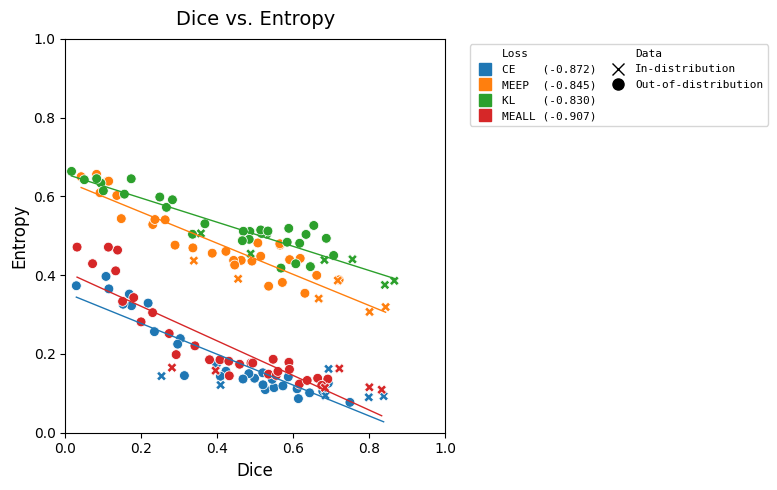

In [25]:
dice_vs_entropy(plot_data, entropy_mask='softmax_pos_class',
                loss_centers_tendencies=False, loss_tendencies=True,
                print_ideal=False, logit_dice=False)

In [28]:

import nibabel as nib


def uncertainty_confusion(plot_data, n_samples=1000):
    centers_train, runs_to_compare, centers_test, test_splits, losses = plot_data.values()

    # Map for renaming test centers
    test_center_rename = {
        "UtAmSi": "In-distribution",
        "UMCL": "Out-of-distribution"
    }

    for tr_center in centers_train:  # Three plots: one per training center
        plot_data = {}  # Entropy scores for each run
        mean_data = {}
        median_data = {}
        for loss in losses:  # One subplot per loss
            plot_data[loss] = {}  # Three uncertainty plots per loss
            mean_data[loss] = {}
            median_data[loss] = {}
            run_name = runs_to_compare[f'{loss} {tr_center}']
            if f'{loss} {tr_center}' not in runs_to_compare.keys():
                print(f'No run for {run_name}.')
                continue
            for ts_center in centers_test:  # For each center used for testing
                plot_data[loss][ts_center] = {
                    "TP": np.array([]),
                    "FP": np.array([]),
                    "TN": np.array([]),
                    "FN": np.array([])
                }
                mean_data[loss][ts_center] = {}
                median_data[loss][ts_center] = {}
                gt_pths = get_gt_paths(
                    test_splits[ts_center])  # List of test subject paths
                for subj_path in gt_pths:
                    pred_softmax_path = os.path.join(
                        subj_path, f'pred_wmh_softmax_{run_name}.nii.gz'
                    )
                    gt_path = os.path.join(subj_path,
                                           f'gt_wmh_{run_name}.nii.gz')

                    subj_path = os.path.dirname(pred_softmax_path)

                    pred_softmax = nib.load(pred_softmax_path).get_fdata()
                    gt = nib.load(gt_path).get_fdata()
                    b_mask = nib.load(get_b_mask_path(subj_path)).get_fdata()

                    gt_one_hot = np.eye(2, dtype=np.uint8)[gt.astype(int)]

                    neg_sftmx = pred_softmax[:, :, :, 0].flatten()
                    pos_sftmx = pred_softmax[:, :, :, 1].flatten()
                    neg_gt = gt_one_hot[:, :, :, 0].flatten()
                    pos_gt = gt_one_hot[:, :, :, 1].flatten()

                    b_mask = b_mask.flatten()

                    # Brain mask
                    thres_brain = np.where(b_mask == 1)[0]
                    pos_brain = pos_sftmx[thres_brain]
                    neg_brain = neg_sftmx[thres_brain]
                    pos_gt_brain = pos_gt[thres_brain]
                    neg_gt_brain = neg_gt[thres_brain]

                    # TP
                    tp = np.where((pos_brain >= 0.5) & (pos_gt_brain == 1))[0]
                    tp_unc = entropy(pos_brain[tp], apply_mean=False)
                    plot_data[loss][ts_center]["TP"] = np.append(
                        plot_data[loss][ts_center]["TP"], tp_unc)

                    # FP
                    fp = np.where((pos_brain >= 0.5) & (pos_gt_brain == 0))[0]
                    fp_unc = entropy(pos_brain[fp], apply_mean=False)
                    plot_data[loss][ts_center]["FP"] = np.append(
                        plot_data[loss][ts_center]["FP"], fp_unc)

                    # TN
                    tn = np.where((neg_brain >= 0.5) & (neg_gt_brain == 1))[0]
                    tn_unc = entropy(neg_brain[tn], apply_mean=False)
                    plot_data[loss][ts_center]["TN"] = np.append(
                        plot_data[loss][ts_center]["TN"], tn_unc)

                    # FN
                    fn = np.where((neg_brain >= 0.5) & (neg_gt_brain == 0))[0]
                    fn_unc = entropy(neg_brain[fn], apply_mean=False)
                    plot_data[loss][ts_center]["FN"] = np.append(
                        plot_data[loss][ts_center]["FN"], fn_unc)

                    # Since there are too many points on TN, we will sample all categories
                    # for having just 100 samples
                    if n_samples:
                        for category in plot_data[loss][ts_center].keys():
                            if len(plot_data[loss][ts_center][
                                       category]) > n_samples:
                                plot_data[loss][ts_center][
                                    category] = np.random.choice(
                                    plot_data[loss][ts_center][category],
                                    n_samples,
                                    replace=False)

                for category in ["TP", "TN", "FP", "FN"]:
                    mean_values = np.mean(plot_data[loss][ts_center][category])
                    median_values = np.median(
                        plot_data[loss][ts_center][category])
                    mean_data[loss][ts_center][category] = mean_values
                    median_data[loss][ts_center][category] = median_values

        # Continue with plotting
        fig, axes = plt.subplots(1, 4, figsize=(32, 4), sharey=True)

        # Create separate strip plots for each error type (TP, TN, FP, FN)
        for i, category in enumerate(["TP", "TN", "FP", "FN"]):
            data = []

            for loss, centers_data in plot_data.items():
                for center, metrics in centers_data.items():
                    renamed_center = test_center_rename.get(center, center)
                    data.extend(
                        [(category, loss, renamed_center, value) for value in
                         metrics[category]])

            df = pd.DataFrame(data,
                              columns=['Metric', 'Loss', 'Test_Center',
                                       'Value'])

            # Create the strip plot
            sns.stripplot(data=df, x='Loss', y='Value', hue='Test_Center',
                          palette={'In-distribution': 'blue',
                                   'Out-of-distribution': 'orange'},
                          jitter=True, alpha=0.2, dodge=True,
                          ax=axes[i])

            # Create the strip plot for mean_data
            mean_df = pd.DataFrame(
                [(category, loss, test_center_rename.get(center, center), value)
                 for loss, centers in
                 mean_data.items() for center, metrics in centers.items() for
                 value in [metrics[category]]],
                columns=['Metric', 'Loss', 'Test_Center', 'Value'])
            sns.stripplot(data=mean_df, x='Loss', y='Value',
                          hue='Test_Center',
                          palette={'In-distribution': 'blue',
                                   'Out-of-distribution': 'orange'},
                          marker='D', size=10, dodge=True, ax=axes[i])

            # Create the strip plot for median_data
            median_df = pd.DataFrame(
                [(category, loss, test_center_rename.get(center, center), value)
                 for loss, centers in
                 median_data.items() for center, metrics in centers.items() for
                 value in [metrics[category]]],
                columns=['Metric', 'Loss', 'Test_Center', 'Value'])
            sns.stripplot(data=median_df, x='Loss', y='Value',
                          hue='Test_Center',
                          palette={'In-distribution': 'blue',
                                   'Out-of-distribution': 'orange'},
                          marker='o', size=10, dodge=True, ax=axes[i])

            axes[i].set_title(f'{category}')
            axes[i].set_xlabel('Loss')
            axes[i].set_ylabel('Value')

            # Remove the legend from the subplot (it will be added later)
            axes[i].get_legend().remove()
            # Add legend only for the last subplot
            if i == 3:
                # Create custom legend elements for mean and median
                white_space = Line2D([0], [0], color='w', markersize=9,
                                     label=' ')
                mean_legend_element = Line2D([0], [0], marker='D', color='w',
                                             markerfacecolor='#ff0000',
                                             markersize=9, label='Mean')
                median_legend_element = Line2D([0], [0], marker='o', color='w',
                                               markerfacecolor='#0000ff',
                                               markersize=9, label='Median')

                # Add custom legend elements to the subplot
                handles, labels = axes[i].get_legend_handles_labels()
                unique_handles_labels = {label: handle for handle, label in
                                         zip(handles, labels)}
                handles = list(unique_handles_labels.values())
                labels = list(unique_handles_labels.keys())
                handles.extend(
                    [white_space, mean_legend_element, median_legend_element])
                labels.extend([' ', 'Mean', ' Median'])
                axes[i].legend(handles=handles, labels=labels,
                               title='Test Center',
                               bbox_to_anchor=(1.05, 1), loc='upper left')

        plt.suptitle(f'Uncertainty plots using {tr_center} for training')
        plt.show()


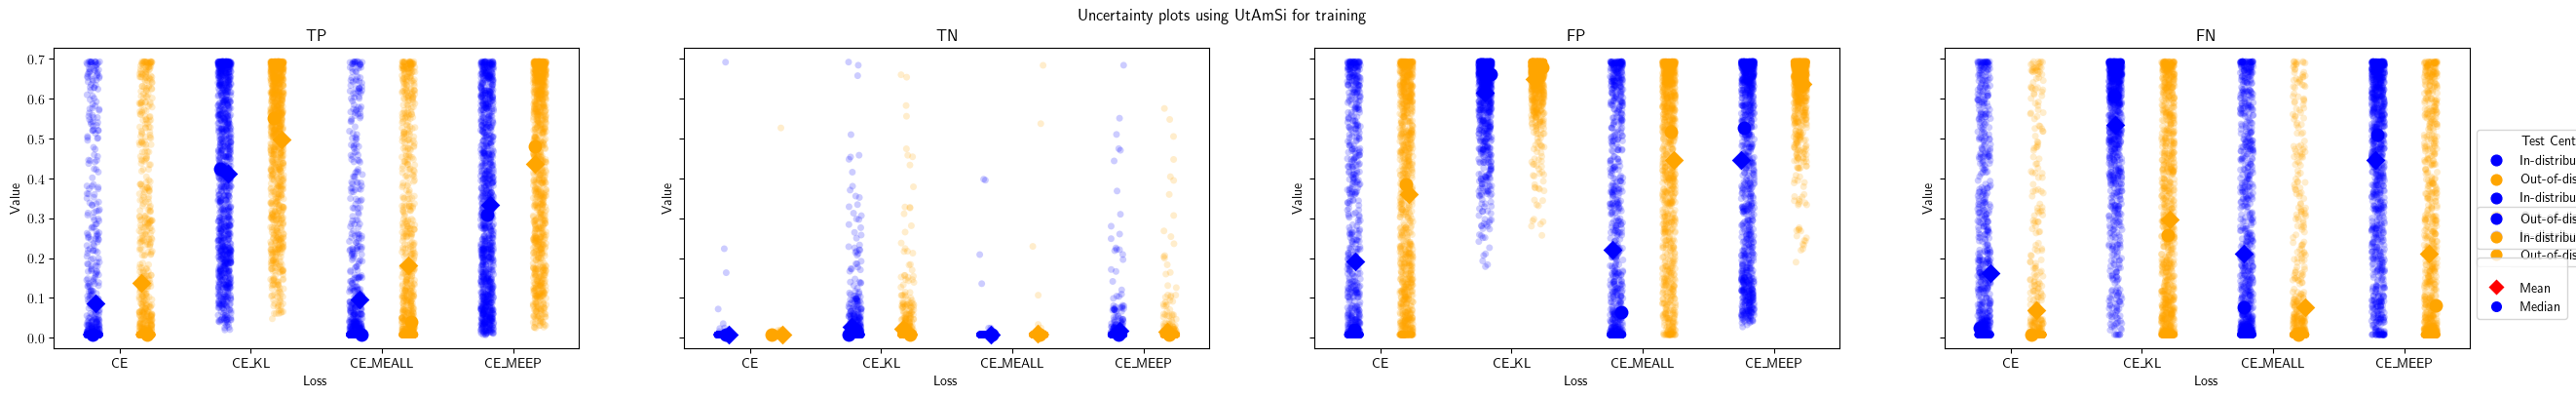

In [31]:
uncertainty_confusion(plot_data, n_samples=1000)

In [ ]:
entropy_boxes(plot_data, m_type='softmax_pos_class',
              rename_labels={'UtAmSi': 'In-distribution',
                             'UMCL': 'Out-of-distribution'})

In [9]:
plot_data

{'centers_train': ['UtAmSi'],
 'runs_to_compare': {'CE UtAmSi': 'training_Utrecht_Amsterdam_Singapore_CE_3684_best',
  'CE_MEALL UtAmSi': 'training_Utrecht_Amsterdam_Singapore_MEALL_8766_best',
  'CE_MEEP UtAmSi': 'training_Utrecht_Amsterdam_Singapore_MEEP_6996_best',
  'CE_KL UtAmSi': 'training_Utrecht_Amsterdam_Singapore_cekl_4187_best',
  'Focal UtAmSi': 'training_Utrecht_Amsterdam_Singapore_Focal_5161_best'},
 'centers_test': ['UMCL', 'UtAmSi'],
 'test_splits': {'UMCL': [['/home/fmatzkin/Code/datasets/wmh/training/UMCL/25/pre/T1.nii.gz',
    '/home/fmatzkin/Code/datasets/wmh/training/UMCL/25/pre/FLAIR.nii.gz',
    '/home/fmatzkin/Code/datasets/wmh/training/UMCL/25/wmh.nii.gz'],
   ['/home/fmatzkin/Code/datasets/wmh/training/UMCL/27/pre/T1.nii.gz',
    '/home/fmatzkin/Code/datasets/wmh/training/UMCL/27/pre/FLAIR.nii.gz',
    '/home/fmatzkin/Code/datasets/wmh/training/UMCL/27/wmh.nii.gz'],
   ['/home/fmatzkin/Code/datasets/wmh/training/UMCL/10/pre/T1.nii.gz',
    '/home/fmatzkin/Code

## Plots

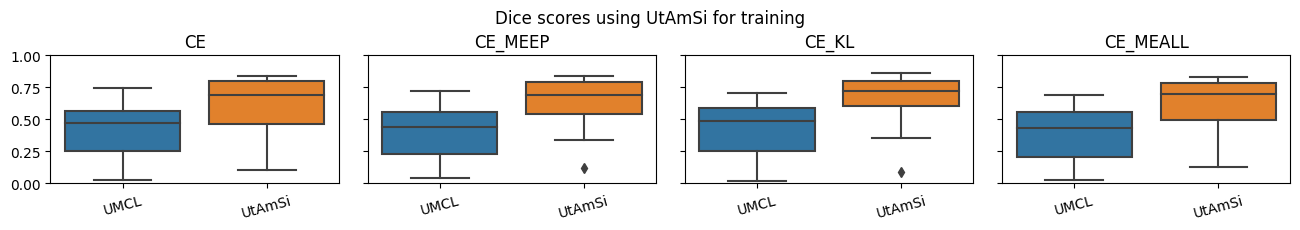

In [8]:
dice(plot_data, use_brain_mask=False)

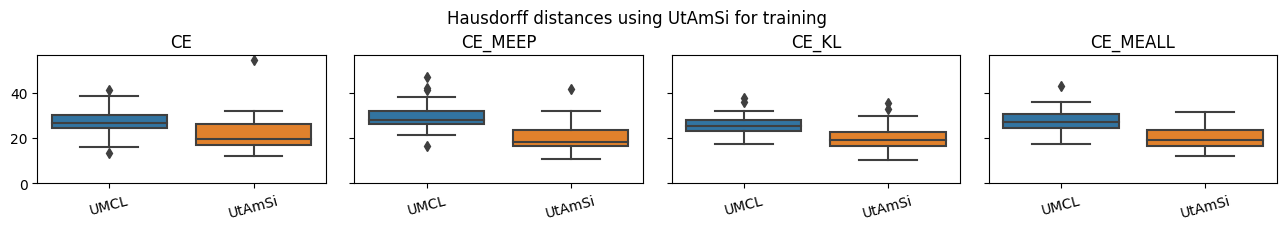

In [6]:
hausdorff(plot_data, use_brain_mask=False)

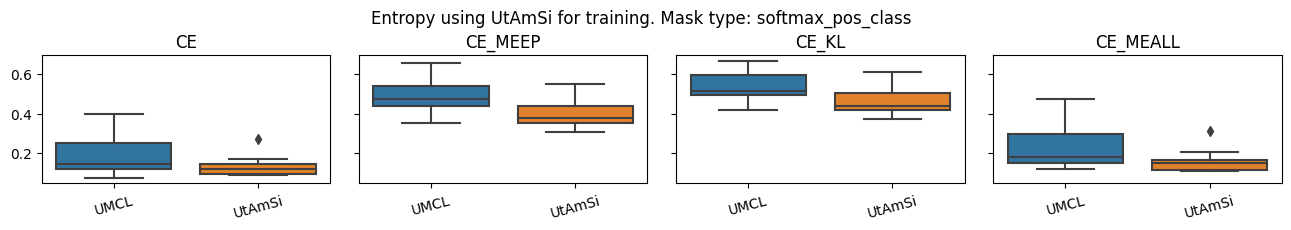

Mann-Whitney U test results for UtAmSi training:
Loss: CE, Test Centers: UMCL vs UtAmSi, p-value: 0.0640957712891108
Loss: CE, Test Centers: UtAmSi vs UMCL, p-value: 0.0640957712891108
Loss: CE_MEEP, Test Centers: UMCL vs UtAmSi, p-value: 0.0015771428701617436
Loss: CE_MEEP, Test Centers: UtAmSi vs UMCL, p-value: 0.0015771428701617436
Loss: CE_KL, Test Centers: UMCL vs UtAmSi, p-value: 0.006635096006711722
Loss: CE_KL, Test Centers: UtAmSi vs UMCL, p-value: 0.006635096006711722
Loss: CE_MEALL, Test Centers: UMCL vs UtAmSi, p-value: 0.012706679316094907
Loss: CE_MEALL, Test Centers: UtAmSi vs UMCL, p-value: 0.012706679316094907


In [7]:
entropy_boxes(plot_data, m_type='softmax_pos_class')

In [78]:



def entropy_boxes(plot_data, m_type='softmax_pos_class'):
    """ Plot entropy scores for each run

    :param plot_data: Dictionary with the required data for plotting (same
    for all plotting functions)
    :param m_type: Type of mask to use for entropy calculation. Options:
    'softmax_pos_class', 'gt', 'brain_mask'.
    """

    centers_train, runs_to_compare, centers_test, test_splits, losses = plot_data.values()

    test_center_rename = {
        "UtAmSi": "In-distribution",
        "UMCL": "Out-of-distribution"
    }

    for tr_center in centers_train:  # Three plots: one per center used for training
        plot_data = {}  # Entropy scores for each run
        for loss in losses:  # One subplot per loss
            plot_data[loss] = {}
            run_name = runs_to_compare[f'{loss} {tr_center}']
            if f'{loss} {tr_center}' not in runs_to_compare.keys():
                print(f'No run for {run_name}.')
                continue
            for ts_center in centers_test:  # For each center used for testing
                renamed_center = test_center_rename.get(ts_center, ts_center)
                plot_data[loss][renamed_center] = []
                gt_pths = get_gt_paths(
                    test_splits[ts_center])  # Lst of tst sbj pts
                for subj_path in gt_pths:
                    gt_path = os.path.join(subj_path,
                                           f'gt_wmh_{run_name}.nii.gz')
                    pred_softmax_path = os.path.join(subj_path,
                                                     f'pred_wmh_softmax_{run_name}.nii.gz')

                    gt = nib.load(gt_path).get_fdata()
                    pred_softmax = nib.load(pred_softmax_path).get_fdata()
                    b_mask = nib.load(
                        get_b_mask_path(subj_path)).get_fdata()

                    pos_class = pred_softmax[:, :, :, 1].flatten()
                    gt_class = gt.flatten()
                    b_mask = b_mask.flatten()

                    if m_type == 'softmax_pos_class':
                        filt = pos_class[np.where(pos_class >= 0.5)[0]]
                    elif m_type == 'gt':
                        filt = pos_class[np.where(gt_class == 1)[0]]
                    else:
                        filt = pos_class[np.where(b_mask == 1)[0]]

                    plot_data[loss][renamed_center].append(entropy(filt))
        df = pd.DataFrame(plot_data)

        # Prepare data for plotting
        plot_df = []
        for loss in losses:
            for ts_center in centers_test:
                renamed_center = test_center_rename.get(ts_center, ts_center)
                entropy_values = plot_data[loss][renamed_center]
                plot_df.extend([{
                    'Loss': loss,
                    'Distribution': renamed_center,
                    'Entropy': value
                } for value in entropy_values])

        df = pd.DataFrame(plot_df)

        # Set up the plot
        plt.figure(figsize=(8, 3))
        sns.set_style("whitegrid")
        sns.set_palette("deep")

        # Create the box plot with reversed hue order
        ax = sns.boxplot(x="Loss", y="Entropy", hue="Distribution", data=df,
                         width=0.7, fliersize=2,
                         hue_order=["In-distribution", "Out-of-distribution"])

        # Add statistical annotations
        box_pairs = []
        for loss in losses:
            box_pairs.append(
                ((loss, "In-distribution"), (loss, "Out-of-distribution")))

        add_stat_annotation(ax, data=df, x="Loss", y="Entropy",
                            hue="Distribution",
                            box_pairs=box_pairs,
                            test='Mann-Whitney', text_format='star',
                            loc='inside', verbose=2)

        # Customize the plot
        plt.title("Entropy per loss and distribution", fontsize=14)
        plt.xlabel("Loss Function", fontsize=12)
        plt.ylabel("Entropy", fontsize=12)

        # Move legend outside and to the right
        plt.legend(title="Distribution", title_fontsize=12, fontsize=10,
                   bbox_to_anchor=(1.05, 1), loc='upper left')

        # Remove x-axis label rotation
        plt.xticks(rotation=0)

        # Adjust layout and display
        plt.tight_layout()
        plt.show()

        # Compute and print Mann-Whitney U tests
        print(f'Mann-Whitney U test results for {tr_center} training:')
        for loss in losses:
            renamed_centers = [test_center_rename.get(c, c) for c in
                               centers_test]
            for ts_center_1 in renamed_centers:
                for ts_center_2 in renamed_centers:
                    if ts_center_1 != ts_center_2:
                        data1 = plot_data[loss][ts_center_1]
                        data2 = plot_data[loss][ts_center_2]
                        stat, p_value = stats.mannwhitneyu(data1, data2,
                                                           alternative='two-sided')
                        print(
                            f'Loss: {loss}, Test Centers: {ts_center_1} vs {ts_center_2}, p-value: {p_value}')

p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

CE_MEEP_Out-of-distribution v.s. CE_MEEP_In-distribution: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=6.309e-03 U_stat=2.940e+02
CE_Out-of-distribution v.s. CE_In-distribution: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=2.564e-01 U_stat=2.470e+02
CE_KL_Out-of-distribution v.s. CE_KL_In-distribution: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=2.654e-02 U_stat=2.780e+02
CE_MEALL_Out-of-distribution v.s. CE_MEALL_In-distribution: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=5.083e-02 U_stat=2.700e+02


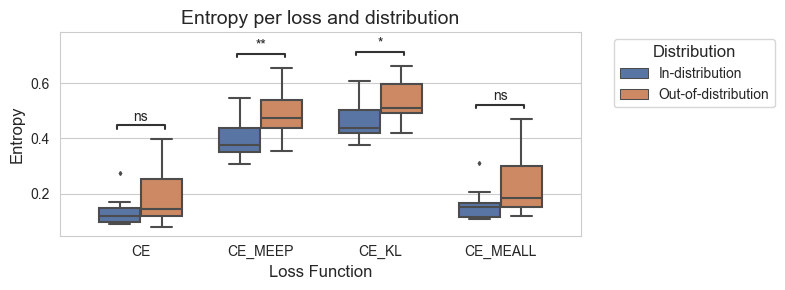

Mann-Whitney U test results for UtAmSi training:
Loss: CE, Test Centers: Out-of-distribution vs In-distribution, p-value: 0.0640957712891108
Loss: CE, Test Centers: In-distribution vs Out-of-distribution, p-value: 0.0640957712891108
Loss: CE_MEEP, Test Centers: Out-of-distribution vs In-distribution, p-value: 0.0015771428701617436
Loss: CE_MEEP, Test Centers: In-distribution vs Out-of-distribution, p-value: 0.0015771428701617436
Loss: CE_KL, Test Centers: Out-of-distribution vs In-distribution, p-value: 0.006635096006711722
Loss: CE_KL, Test Centers: In-distribution vs Out-of-distribution, p-value: 0.006635096006711722
Loss: CE_MEALL, Test Centers: Out-of-distribution vs In-distribution, p-value: 0.012706679316094907
Loss: CE_MEALL, Test Centers: In-distribution vs Out-of-distribution, p-value: 0.012706679316094907


In [79]:
entropy_boxes(plot_data, m_type='softmax_pos_class')

In [11]:
from statannot import add_stat_annotation
from scipy import stats


def dice_boxes(plot_data):
    """ Plot Dice scores for each run

    :param plot_data: Dictionary with the required data for plotting
    """
    centers_train, runs_to_compare, centers_test, test_splits, losses = plot_data.values()

    test_center_rename = {
        "UtAmSi": "In-distribution",
        "UMCL": "Out-of-distribution"
    }

    for tr_center in centers_train:  # One plot per center used for training
        plot_data = {}  # Dice scores for each run
        for loss in losses:  # One subplot per loss
            plot_data[loss] = {}
            run_name = runs_to_compare[f'{loss} {tr_center}']
            if f'{loss} {tr_center}' not in runs_to_compare.keys():
                print(f'No run for {run_name}.')
                continue
            for ts_center in centers_test:  # For each center used for testing
                renamed_center = test_center_rename.get(ts_center, ts_center)
                plot_data[loss][renamed_center] = []
                gt_pths = get_gt_paths(
                    test_splits[ts_center])  # List of test subject paths
                for subj_path in gt_pths:
                    gt_path = os.path.join(subj_path,
                                           f'gt_wmh_{run_name}.nii.gz')
                    pred_softmax_path = os.path.join(subj_path,
                                                     f'pred_wmh_softmax_{run_name}.nii.gz')

                    gt = nib.load(gt_path).get_fdata()
                    pred_softmax = nib.load(pred_softmax_path).get_fdata()

                    # Convert softmax predictions to binary mask
                    pred_binary = (pred_softmax[:, :, :, 1] >= 0.5).astype(int)

                    # Compute Dice score
                    dice = dice_score(gt, pred_binary)
                    plot_data[loss][renamed_center].append(dice)

        # Prepare data for plotting
        plot_df = []
        for loss in losses:
            for ts_center in centers_test:
                renamed_center = test_center_rename.get(ts_center, ts_center)
                dice_values = plot_data[loss][renamed_center]
                plot_df.extend([{
                    'Loss': loss,
                    'Distribution': renamed_center,
                    'Dice Score': value
                } for value in dice_values])

        df = pd.DataFrame(plot_df)

        # Set up the plot
        plt.figure(figsize=(8, 3))
        sns.set_style("whitegrid")
        sns.set_palette("deep")

        # Create the box plot with reversed hue order
        ax = sns.boxplot(x="Loss", y="Dice Score", hue="Distribution", data=df,
                         width=0.7, fliersize=2,
                         hue_order=["In-distribution", "Out-of-distribution"])

        # Add statistical annotations
        box_pairs = []
        for loss in losses:
            box_pairs.append(
                ((loss, "In-distribution"), (loss, "Out-of-distribution")))

        add_stat_annotation(ax, data=df, x="Loss", y="Dice Score",
                            hue="Distribution",
                            box_pairs=box_pairs,
                            test='Mann-Whitney', text_format='star',
                            loc='inside', verbose=2)

        # Customize the plot
        plt.title(f"Dice Coefficient for loss and distribution", fontsize=14)
        plt.xlabel("Loss Function", fontsize=12)
        plt.ylabel("Dice Score", fontsize=12)

        # Move legend outside and to the right
        plt.legend(title="Distribution", title_fontsize=12, fontsize=10,
                   bbox_to_anchor=(1.05, 1), loc='upper left')

        # Remove x-axis label rotation
        plt.xticks(rotation=0)

        # Adjust layout and display
        plt.tight_layout()
        plt.show()

        # Compute and print Mann-Whitney U tests
        print(f'Mann-Whitney U test results for {tr_center} training:')
        for loss in losses:
            renamed_centers = [test_center_rename.get(c, c) for c in
                               centers_test]
            for ts_center_1 in renamed_centers:
                for ts_center_2 in renamed_centers:
                    if ts_center_1 != ts_center_2:
                        data1 = plot_data[loss][ts_center_1]
                        data2 = plot_data[loss][ts_center_2]
                        stat, p_value = stats.mannwhitneyu(data1, data2,
                                                           alternative='two-sided')
                        print(
                            f'Loss: {loss}, Test Centers: {ts_center_1} vs {ts_center_2}, p-value: {p_value}')

p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

CE_MEEP_Out-of-distribution v.s. CE_MEEP_In-distribution: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=8.376e-03 U_stat=6.900e+01
CE_Out-of-distribution v.s. CE_In-distribution: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=4.698e-02 U_stat=8.900e+01
CE_KL_Out-of-distribution v.s. CE_KL_In-distribution: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=8.376e-03 U_stat=6.900e+01
CE_MEALL_Out-of-distribution v.s. CE_MEALL_In-distribution: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=2.056e-02 U_stat=7.900e+01


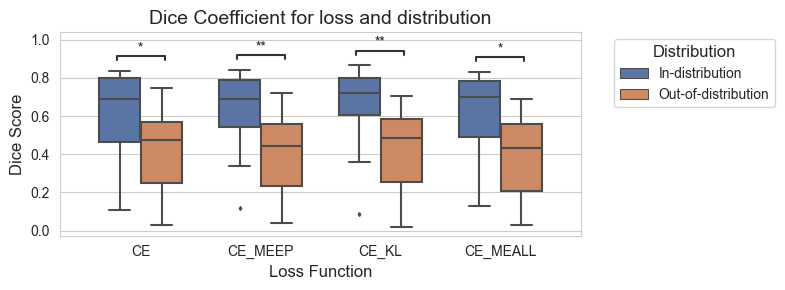

Mann-Whitney U test results for UtAmSi training:
Loss: CE, Test Centers: Out-of-distribution vs In-distribution, p-value: 0.011744543066279579
Loss: CE, Test Centers: In-distribution vs Out-of-distribution, p-value: 0.011744543066279579
Loss: CE_MEEP, Test Centers: Out-of-distribution vs In-distribution, p-value: 0.002093940351095057
Loss: CE_MEEP, Test Centers: In-distribution vs Out-of-distribution, p-value: 0.002093940351095057
Loss: CE_KL, Test Centers: Out-of-distribution vs In-distribution, p-value: 0.002093940351095057
Loss: CE_KL, Test Centers: In-distribution vs Out-of-distribution, p-value: 0.002093940351095057
Loss: CE_MEALL, Test Centers: Out-of-distribution vs In-distribution, p-value: 0.00513960179037091
Loss: CE_MEALL, Test Centers: In-distribution vs Out-of-distribution, p-value: 0.00513960179037091


In [12]:
dice_boxes(plot_data)

In [21]:



def uncertainty_confusion(plot_data, n_samples=1000):
    centers_train, runs_to_compare, centers_test, test_splits, losses = plot_data.values()

    test_center_rename = {
        "UtAmSi": "In-distribution",
        "UMCL": "Out-of-distribution"
    }

    for tr_center in centers_train:
        plot_data = {}
        mean_data = {}
        median_data = {}
        for loss in losses:
            plot_data[loss] = {}
            mean_data[loss] = {}
            median_data[loss] = {}
            run_name = runs_to_compare[f'{loss} {tr_center}']
            if f'{loss} {tr_center}' not in runs_to_compare.keys():
                print(f'No run for {run_name}.')
                continue
            for ts_center in centers_test:
                plot_data[loss][ts_center] = {
                    "TP": np.array([]),
                    "FP": np.array([]),
                    "TN": np.array([]),
                    "FN": np.array([])
                }
                mean_data[loss][ts_center] = {}
                median_data[loss][ts_center] = {}
                gt_pths = get_gt_paths(test_splits[ts_center])
                for subj_path in gt_pths:
                    pred_softmax_path = os.path.join(subj_path,
                                                     f'pred_wmh_softmax_{run_name}.nii.gz')
                    gt_path = os.path.join(subj_path,
                                           f'gt_wmh_{run_name}.nii.gz')

                    subj_path = os.path.dirname(pred_softmax_path)

                    pred_softmax = nib.load(pred_softmax_path).get_fdata()
                    gt = nib.load(gt_path).get_fdata()
                    b_mask = nib.load(get_b_mask_path(subj_path)).get_fdata()

                    gt_one_hot = np.eye(2, dtype=np.uint8)[gt.astype(int)]

                    neg_sftmx = pred_softmax[:, :, :, 0].flatten()
                    pos_sftmx = pred_softmax[:, :, :, 1].flatten()
                    neg_gt = gt_one_hot[:, :, :, 0].flatten()
                    pos_gt = gt_one_hot[:, :, :, 1].flatten()

                    b_mask = b_mask.flatten()

                    thres_brain = np.where(b_mask == 1)[0]
                    pos_brain = pos_sftmx[thres_brain]
                    neg_brain = neg_sftmx[thres_brain]
                    pos_gt_brain = pos_gt[thres_brain]
                    neg_gt_brain = neg_gt[thres_brain]

                    tp = np.where((pos_brain >= 0.5) & (pos_gt_brain == 1))[0]
                    tp_unc = entropy(pos_brain[tp], apply_mean=False)
                    plot_data[loss][ts_center]["TP"] = np.append(
                        plot_data[loss][ts_center]["TP"], tp_unc)

                    fp = np.where((pos_brain >= 0.5) & (pos_gt_brain == 0))[0]
                    fp_unc = entropy(pos_brain[fp], apply_mean=False)
                    plot_data[loss][ts_center]["FP"] = np.append(
                        plot_data[loss][ts_center]["FP"], fp_unc)

                    tn = np.where((neg_brain >= 0.5) & (neg_gt_brain == 1))[0]
                    tn_unc = entropy(neg_brain[tn], apply_mean=False)
                    plot_data[loss][ts_center]["TN"] = np.append(
                        plot_data[loss][ts_center]["TN"], tn_unc)

                    fn = np.where((neg_brain >= 0.5) & (neg_gt_brain == 0))[0]
                    fn_unc = entropy(neg_brain[fn], apply_mean=False)
                    plot_data[loss][ts_center]["FN"] = np.append(
                        plot_data[loss][ts_center]["FN"], fn_unc)

                    if n_samples:
                        for category in plot_data[loss][ts_center].keys():
                            if len(plot_data[loss][ts_center][
                                       category]) > n_samples:
                                plot_data[loss][ts_center][
                                    category] = np.random.choice(
                                    plot_data[loss][ts_center][category],
                                    n_samples,
                                    replace=False)

                for category in ["TP", "TN", "FP", "FN"]:
                    mean_values = np.mean(plot_data[loss][ts_center][category])
                    median_values = np.median(
                        plot_data[loss][ts_center][category])
                    mean_data[loss][ts_center][category] = mean_values
                    median_data[loss][ts_center][category] = median_values

    fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
    categories = ["TP", "TN", "FP", "FN"]

    for i, category in enumerate(categories):
        data = []
        for distribution in ["In-distribution", "Out-of-distribution"]:
            for loss in losses:
                for center, metrics in plot_data[loss].items():
                    renamed_center = test_center_rename.get(center, center)
                    if renamed_center == distribution:
                        data.extend(
                            [(category, loss, distribution, value) for value in
                             metrics[category]])

        df = pd.DataFrame(data,
                          columns=['Metric', 'Loss', 'Distribution', 'Value'])

        custom_order = df['Loss'].unique()

        x_positions = np.arange(len(custom_order) * 2)

        # Plot all in-distribution first, then all out-of-distribution
        for j, dist in enumerate(['In-distribution', 'Out-of-distribution']):
            df_dist = df[df['Distribution'] == dist]
            color = '#1f77b4' if dist == 'In-distribution' else '#ff7f0e'

            for k, loss in enumerate(custom_order):
                group = df_dist[df_dist['Loss'] == loss]
                x = x_positions[k + j * len(custom_order)]
                y = group['Value']
                axes[i].scatter(x + np.random.normal(0, 0.05, len(y)), y,
                                color=color, alpha=0.2, s=3)

        for marker, data_source in zip(['D', 'o'], [mean_data, median_data]):
            summary_df = pd.DataFrame(
                [(category, loss, test_center_rename.get(center, center), value)
                 for loss, centers in data_source.items()
                 for center, metrics in centers.items()
                 for value in [metrics[category]]],
                columns=['Metric', 'Loss', 'Distribution', 'Value'])

            for j, dist in enumerate(
                    ['In-distribution', 'Out-of-distribution']):
                df_dist = summary_df[summary_df['Distribution'] == dist]
                for k, loss in enumerate(custom_order):
                    group = df_dist[df_dist['Loss'] == loss]
                    if not group.empty:
                        x = x_positions[k + j * len(custom_order)]
                        y = group['Value'].values[0]
                        axes[i].scatter(x, y, color='#d62728', marker=marker,
                                        s=64)

        axes[i].set_title(f'{category}', fontsize=16, pad=10)
        # axes[i].set_xlabel('Loss', fontsize=14)
        if i == 0:
            axes[i].set_ylabel('Entropy', fontsize=14)
        axes[i].tick_params(axis='both', which='major', labelsize=12)
        axes[i].set_xticks(x_positions)
        axes[i].set_xticklabels(custom_order.tolist() * 2, rotation=45,
                                ha='right')

        # Remove background grid lines
        axes[i].grid(False)

    # Create custom legend
    legend_elements = [
        Line2D([0], [0], color='#1f77b4', lw=4, label='In-distribution'),
        Line2D([0], [0], color='#ff7f0e', lw=4, label='Out-of-distribution'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='#d62728',
               markersize=8, label='Mean'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728',
               markersize=8, label='Median')
    ]

    legend = fig.legend(handles=legend_elements,
                        bbox_to_anchor=(0.865, 0.5), loc='center left',
                        fontsize=10)
    legend.get_title().set_fontsize(12)

    fig.text(0.5, 0.002, 'Loss', ha='center', fontsize=14)
    plt.tight_layout()
    plt.suptitle(f'Uncertainty by error type', fontsize=18, y=1.02)
    plt.subplots_adjust(right=0.85)  # Adjust right margin for legend
    plt.show()

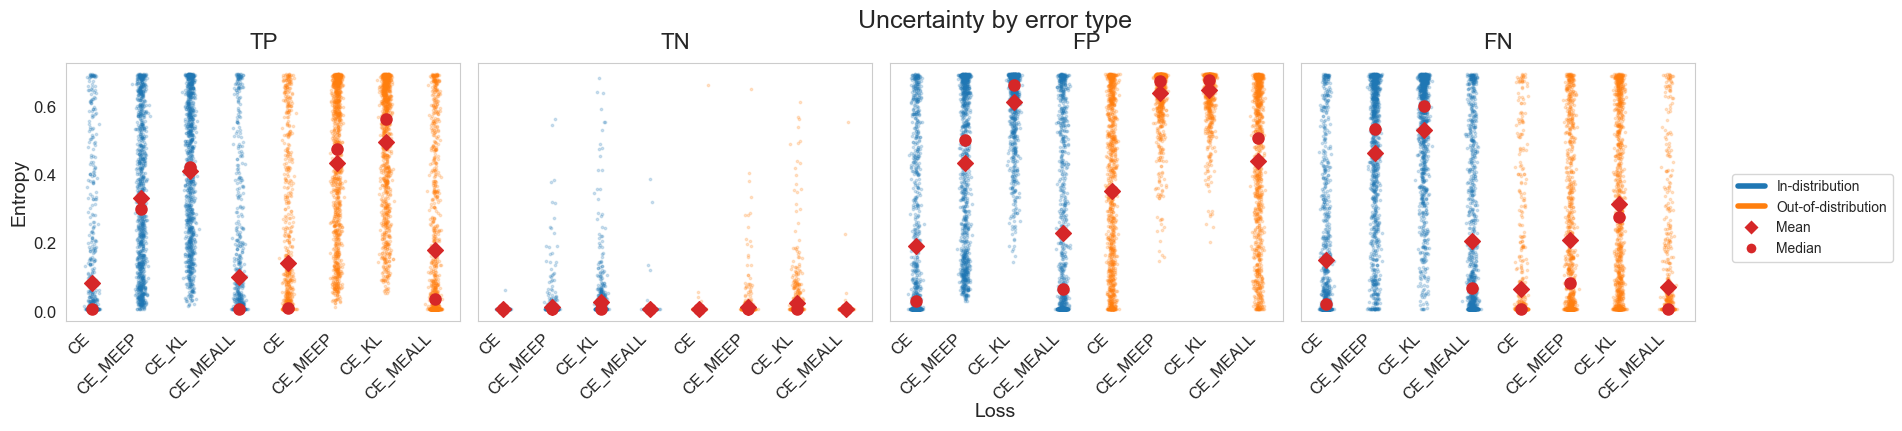

In [22]:
uncertainty_confusion(plot_data, n_samples=1000)

In [24]:
import numpy as np
from matplotlib.lines import Line2D


def uncertainty_confusion(plot_data, n_samples=1000):
    centers_train, runs_to_compare, centers_test, test_splits, losses = plot_data.values()

    test_center_rename = {
        "UtAmSi": "In-distribution",
        "UMCL": "Out-of-distribution"
    }

    for tr_center in centers_train:
        plot_data = {}
        mean_data = {}
        median_data = {}
        for loss in losses:
            plot_data[loss] = {}
            mean_data[loss] = {}
            median_data[loss] = {}
            run_name = runs_to_compare[f'{loss} {tr_center}']
            if f'{loss} {tr_center}' not in runs_to_compare.keys():
                print(f'No run for {run_name}.')
                continue
            for ts_center in centers_test:
                plot_data[loss][ts_center] = {
                    "TP": np.array([]),
                    "FP": np.array([]),
                    "TN": np.array([]),
                    "FN": np.array([])
                }
                mean_data[loss][ts_center] = {}
                median_data[loss][ts_center] = {}
                gt_pths = get_gt_paths(test_splits[ts_center])
                for subj_path in gt_pths:
                    pred_softmax_path = os.path.join(subj_path,
                                                     f'pred_wmh_softmax_{run_name}.nii.gz')
                    gt_path = os.path.join(subj_path,
                                           f'gt_wmh_{run_name}.nii.gz')

                    subj_path = os.path.dirname(pred_softmax_path)

                    pred_softmax = nib.load(pred_softmax_path).get_fdata()
                    gt = nib.load(gt_path).get_fdata()
                    b_mask = nib.load(get_b_mask_path(subj_path)).get_fdata()

                    gt_one_hot = np.eye(2, dtype=np.uint8)[gt.astype(int)]

                    neg_sftmx = pred_softmax[:, :, :, 0].flatten()
                    pos_sftmx = pred_softmax[:, :, :, 1].flatten()
                    neg_gt = gt_one_hot[:, :, :, 0].flatten()
                    pos_gt = gt_one_hot[:, :, :, 1].flatten()

                    b_mask = b_mask.flatten()

                    thres_brain = np.where(b_mask == 1)[0]
                    pos_brain = pos_sftmx[thres_brain]
                    neg_brain = neg_sftmx[thres_brain]
                    pos_gt_brain = pos_gt[thres_brain]
                    neg_gt_brain = neg_gt[thres_brain]

                    tp = np.where((pos_brain >= 0.5) & (pos_gt_brain == 1))[0]
                    tp_unc = entropy(pos_brain[tp], apply_mean=False)
                    plot_data[loss][ts_center]["TP"] = np.append(
                        plot_data[loss][ts_center]["TP"], tp_unc)

                    fp = np.where((pos_brain >= 0.5) & (pos_gt_brain == 0))[0]
                    fp_unc = entropy(pos_brain[fp], apply_mean=False)
                    plot_data[loss][ts_center]["FP"] = np.append(
                        plot_data[loss][ts_center]["FP"], fp_unc)

                    tn = np.where((neg_brain >= 0.5) & (neg_gt_brain == 1))[0]
                    tn_unc = entropy(neg_brain[tn], apply_mean=False)
                    plot_data[loss][ts_center]["TN"] = np.append(
                        plot_data[loss][ts_center]["TN"], tn_unc)

                    fn = np.where((neg_brain >= 0.5) & (neg_gt_brain == 0))[0]
                    fn_unc = entropy(neg_brain[fn], apply_mean=False)
                    plot_data[loss][ts_center]["FN"] = np.append(
                        plot_data[loss][ts_center]["FN"], fn_unc)

                    if n_samples:
                        for category in plot_data[loss][ts_center].keys():
                            if len(plot_data[loss][ts_center][
                                       category]) > n_samples:
                                plot_data[loss][ts_center][
                                    category] = np.random.choice(
                                    plot_data[loss][ts_center][category],
                                    n_samples,
                                    replace=False)

                for category in ["TP", "TN", "FP", "FN"]:
                    mean_values = np.mean(plot_data[loss][ts_center][category])
                    median_values = np.median(
                        plot_data[loss][ts_center][category])
                    mean_data[loss][ts_center][category] = mean_values
                    median_data[loss][ts_center][category] = median_values

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)
    axes = axes.flatten()  # Flatten the 2x2 grid to iterate easily
    categories = ["TP", "TN", "FP", "FN"]

    for i, category in enumerate(categories):
        data = []
        for distribution in ["In-distribution", "Out-of-distribution"]:
            for loss in losses:
                for center, metrics in plot_data[loss].items():
                    renamed_center = test_center_rename.get(center, center)
                    if renamed_center == distribution:
                        data.extend(
                            [(category, loss, distribution, value) for value in
                             metrics[category]])

        df = pd.DataFrame(data,
                          columns=['Metric', 'Loss', 'Distribution', 'Value'])

        custom_order = df['Loss'].unique()

        x_positions = np.arange(len(custom_order) * 2)

        # Plot all in-distribution first, then all out-of-distribution
        for j, dist in enumerate(['In-distribution', 'Out-of-distribution']):
            df_dist = df[df['Distribution'] == dist]
            color = '#1f77b4' if dist == 'In-distribution' else '#ff7f0e'

            for k, loss in enumerate(custom_order):
                group = df_dist[df_dist['Loss'] == loss]
                x = x_positions[k + j * len(custom_order)]
                y = group['Value']
                axes[i].scatter(x + np.random.normal(0, 0.05, len(y)), y,
                                color=color, alpha=0.2, s=3)

        for marker, data_source in zip(['D', 'o'], [mean_data, median_data]):
            summary_df = pd.DataFrame(
                [(category, loss, test_center_rename.get(center, center), value)
                 for loss, centers in data_source.items()
                 for center, metrics in centers.items()
                 for value in [metrics[category]]],
                columns=['Metric', 'Loss', 'Distribution', 'Value'])

            for j, dist in enumerate(
                    ['In-distribution', 'Out-of-distribution']):
                df_dist = summary_df[summary_df['Distribution'] == dist]
                for k, loss in enumerate(custom_order):
                    group = df_dist[df_dist['Loss'] == loss]
                    if not group.empty:
                        x = x_positions[k + j * len(custom_order)]
                        y = group['Value'].values[0]
                        axes[i].scatter(x, y, color='#d62728', marker=marker,
                                        s=64)

        axes[i].set_title(f'{category}', fontsize=16, pad=10)
        # axes[i].set_xlabel('Loss', fontsize=14)
        if i == 0:
            axes[i].set_ylabel('Entropy', fontsize=14)
        axes[i].tick_params(axis='both', which='major', labelsize=12)
        axes[i].set_xticks(x_positions)
        axes[i].set_xticklabels(custom_order.tolist() * 2, rotation=45,
                                ha='right')

        # Remove background grid lines
        axes[i].grid(False)

    # Create custom legend
    legend_elements = [
        Line2D([0], [0], color='#1f77b4', lw=4, label='In-distribution'),
        Line2D([0], [0], color='#ff7f0e', lw=4, label='Out-of-distribution'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='#d62728',
               markersize=8, label='Mean'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728',
               markersize=8, label='Median')
    ]

    legend = fig.legend(handles=legend_elements,
                        bbox_to_anchor=(0.865, 0.5), loc='center left',
                        fontsize=10)
    legend.get_title().set_fontsize(12)

    fig.text(0.5, 0.002, 'Loss', ha='center', fontsize=14)
    plt.tight_layout()
    plt.suptitle(f'Uncertainty by error type', fontsize=18, y=1.05)
    plt.subplots_adjust(right=0.85)  # Adjust right margin for legend
    plt.show()

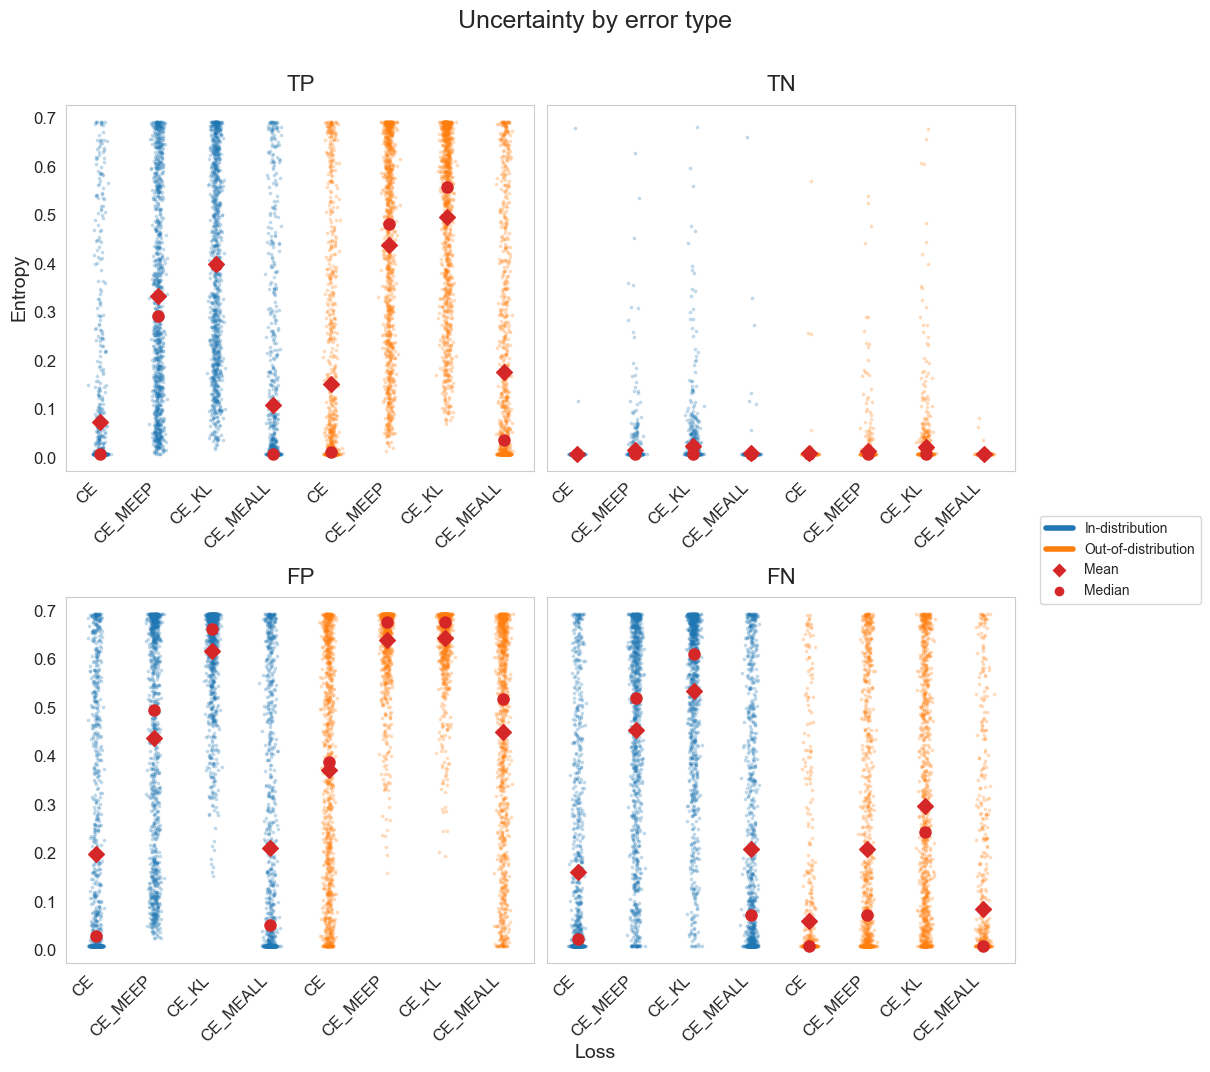

In [25]:
uncertainty_confusion(plot_data, n_samples=1000)

In [59]:
mcdropout_boxes(plot_data)

FileNotFoundError: No such file or no access: '/home/fmatzkin/Code/datasets/wmh/training/UMCL/25/pred_mc_uncertmc_training_Utrecht_Amsterdam_Singapore_cekl_4187_best.nii.gz'

In [11]:
volume_ranges = [(0, 5), (5, 15), (15, np.inf)]

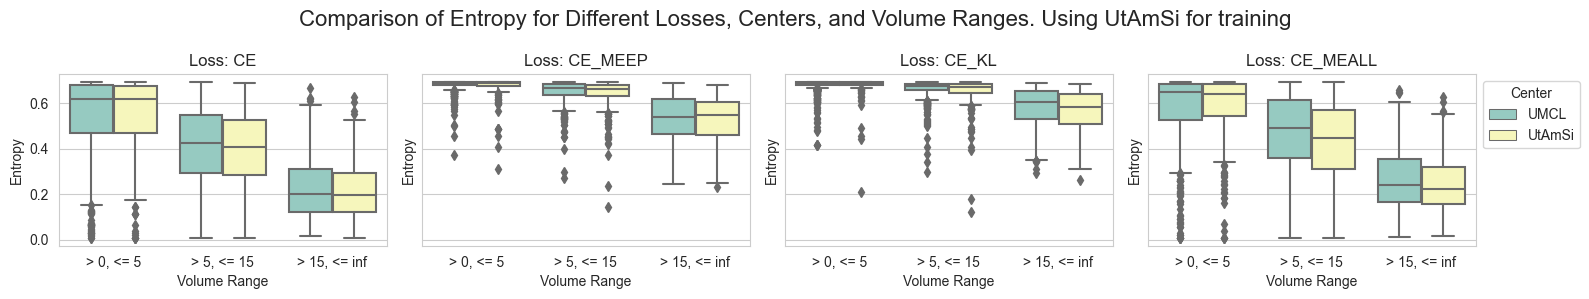

In [27]:
from notebooks.metrics.utils import entropy_volume_ranges

entropy_volume_ranges(plot_data, volume_ranges)

In [ ]:

import numpy as np
from scipy.stats import entropy


def entropy_volume_ranges(plot_data,
                          volume_ranges=((0, 5), (5, 15), (15, np.inf))):
    centers_train, runs_to_compare, centers_test, test_splits, losses = plot_data.values()

    rename_centers = {'UtAmSi': 'In-distribution',
                      'UMCL': 'Out-of-distribution'}
    loss_order = ['CE', 'CE_MEALL', 'CE_MEEP', 'CE_KL']

    for tr_center in centers_train:
        plot_data = {}
        for loss in losses:
            plot_data[loss] = {}
            run_name = runs_to_compare[f'{loss} {tr_center}']
            if f'{loss} {tr_center}' not in runs_to_compare.keys():
                print(f'No run for {run_name}.')
                continue
            for ts_center in centers_test:
                plot_data[loss][ts_center] = {
                    f"> {volume_ranges[i][0]}, <= {volume_ranges[i][1]}": []
                    for i in range(len(volume_ranges))
                }
                gt_pths = get_gt_paths(test_splits[ts_center])
                for subj_path in gt_pths:
                    pred_softmax_path = os.path.join(subj_path,
                                                     f'pred_wmh_softmax_{run_name}.nii.gz')

                    pred_softmax = sitk.ReadImage(pred_softmax_path)
                    hard_pred = sitk.GetArrayFromImage(pred_softmax).argmax(
                        axis=0)

                    cc = sitk.ConnectedComponent(sitk.GetImageFromArray(
                        (hard_pred > 0).astype(np.uint8)))
                    cc = sitk.RelabelComponent(cc)

                    for i in range(1, sitk.GetArrayFromImage(cc).max() + 1):
                        cc_mask_f = sitk.GetArrayFromImage(cc == i).flatten()
                        filt = np.where(cc_mask_f == 1)[0]
                        volume = len(filt) * np.prod(pred_softmax.GetSpacing())
                        sftmx_f = \
                            sitk.GetArrayFromImage(pred_softmax).flatten()[filt]
                        ent = entropy(sftmx_f)

                        for i, (lower, upper) in enumerate(volume_ranges):
                            if lower < volume <= upper:
                                plot_data[loss][ts_center][
                                    f"> {lower}, <= {upper}"].append(ent)
                                break

        # Prepare the data for plotting
        data = []
        for loss in losses:
            for center in centers_test:
                for range_label, entropies in plot_data[loss][center].items():
                    renamed_center = rename_centers.get(center, center)
                    data.extend(
                        [(loss, renamed_center, range_label, ent) for ent in
                         entropies])

        df = pd.DataFrame(data,
                          columns=['Loss', 'Center', 'Volume Range', 'Entropy'])

        # Create a single plot
        plt.figure(figsize=(20, 6))

        # Define the order of centers
        center_order = ['In-distribution', 'Out-of-distribution']

        # Create a boxplot for each volume range
        for i, volume_range in enumerate(df['Volume Range'].unique()):
            ax = plt.subplot(1, 3, i + 1)

            # Filter the DataFrame for the current volume range
            range_df = df[df['Volume Range'] == volume_range]

            # Create boxplots for each loss and center
            sns.boxplot(data=range_df, x='Loss', y='Entropy', hue='Center',
                        order=loss_order, hue_order=center_order,
                        palette={'In-distribution': 'lightgreen',
                                 'Out-of-distribution': 'lightblue'})

            plt.title(f'Volume Range: {volume_range}')
            plt.xlabel('Loss')
            plt.ylabel('Entropy')

            # Rotate x-axis labels for better readability
            plt.xticks(rotation=45)

            # Only show legend for the last subplot
            if i < 2:
                plt.legend([], [], frameon=False)

        # Set the overall title for the entire plot
        plt.suptitle(
            'Comparison of Entropy for Different Losses, Centers, and '
            f'Volume Ranges. Using {tr_center} for training',
            fontsize=16)

        # Adjust the layout
        plt.tight_layout()
        plt.show()

# You would call this function with your plot_data dictionary as before

In [ ]:

import numpy as np


def entropy_volume_ranges(plot_data,
                          volume_ranges=((0, 5), (5, 15), (15, np.inf))):
    centers_train, runs_to_compare, centers_test, test_splits, losses = plot_data.values()

    rename_centers = {'UtAmSi': 'In-distribution',
                      'UMCL': 'Out-of-distribution'}
    loss_order = ['CE', 'CE_MEALL', 'CE_MEEP', 'CE_KL']

    for tr_center in centers_train:
        plot_data = {}
        for loss in losses:
            plot_data[loss] = {}
            run_name = runs_to_compare[f'{loss} {tr_center}']
            if f'{loss} {tr_center}' not in runs_to_compare.keys():
                print(f'No run for {run_name}.')
                continue
            for ts_center in centers_test:
                plot_data[loss][ts_center] = {
                    f"> {volume_ranges[i][0]}, <= {volume_ranges[i][1]}": []
                    for i in range(len(volume_ranges))
                }
                gt_pths = get_gt_paths(test_splits[ts_center])
                for subj_path in gt_pths:
                    pred_softmax_path = os.path.join(subj_path,
                                                     f'pred_wmh_softmax_{run_name}.nii.gz')

                    pred_softmax = sitk.ReadImage(pred_softmax_path)
                    hard_pred = sitk.GetArrayFromImage(pred_softmax).argmax(
                        axis=0)

                    cc = sitk.ConnectedComponent(sitk.GetImageFromArray(
                        (hard_pred > 0).astype(np.uint8)))
                    cc = sitk.RelabelComponent(cc)

                    for i in range(1, sitk.GetArrayFromImage(cc).max() + 1):
                        cc_mask_f = sitk.GetArrayFromImage(cc == i).flatten()
                        filt = np.where(cc_mask_f == 1)[0]
                        volume = len(filt) * np.prod(pred_softmax.GetSpacing())
                        sftmx_f = \
                            sitk.GetArrayFromImage(pred_softmax).flatten()[filt]
                        ent = entropy(sftmx_f, apply_mean=True)

                        for i, (lower, upper) in enumerate(volume_ranges):
                            if lower < volume <= upper:
                                plot_data[loss][ts_center][
                                    f"> {lower}, <= {upper}"].append(ent)
                                break

    # Prepare the data for plotting
    data = []
    for loss in losses:
        for center in centers_test:
            for range_label, entropies in plot_data[loss][center].items():
                renamed_center = rename_centers.get(center, center)
                data.extend([(loss, renamed_center, range_label, ent) for ent in
                             entropies])

    df = pd.DataFrame(data,
                      columns=['Loss', 'Center', 'Volume Range', 'Entropy'])
    # Create a single plot
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

    # Define the order of centers
    center_order = ['In-distribution', 'Out-of-distribution']

    # Find global min and max for consistent y-axis
    # global_min = df['Entropy'].min()
    # global_max = df['Entropy'].max()

    # Create a boxplot for each volume range
    for i, volume_range in enumerate(df['Volume Range'].unique()):
        ax = axes[i]

        # Filter the DataFrame for the current volume range
        range_df = df[df['Volume Range'] == volume_range]

        # Create boxplots for each loss and center
        sns.boxplot(data=range_df, x='Loss', y='Entropy', hue='Center',
                    order=loss_order, hue_order=center_order,
                    palette={'In-distribution': 'lightgreen',
                             'Out-of-distribution': 'lightblue'},
                    ax=ax)

        ax.set_title(f'Volume Range: {volume_range}')
        ax.set_xlabel('Loss')
        ax.set_ylabel('Entropy')

        # Rotate x-axis labels for better readability
        ax.set_xticklabels(ax.get_xticklabels())

        # Set y-axis limits consistently across subplots
        # ax.set_ylim(global_min, global_max)

        # Add median lines
        for i, artist in enumerate(ax.artists):
            col = artist.get_facecolor()
            artist.set_edgecolor(col)
            artist.set_facecolor('None')

            y = range_df[(range_df['Loss'] == loss_order[i // 2]) &
                         (range_df['Center'] == center_order[i % 2])][
                'Entropy'].median()
            ax.hlines(y, *artist.get_xy()[:2], colors=col, linestyles='--',
                      linewidth=2)

        # Only show legend for the last subplot
        if i < 2:
            ax.get_legend().remove()

    #move the legend outside the plot
    plt.legend(title='Center', title_fontsize=12, fontsize=10,
               bbox_to_anchor=(1.05, 1), loc='upper left')

    # Set the overall title for the entire plot
    fig.suptitle('Entropy per volume range', fontsize=16)

    # Adjust the layout
    plt.tight_layout()
    plt.show()

# You would call this function with your plot_data dictionary as before

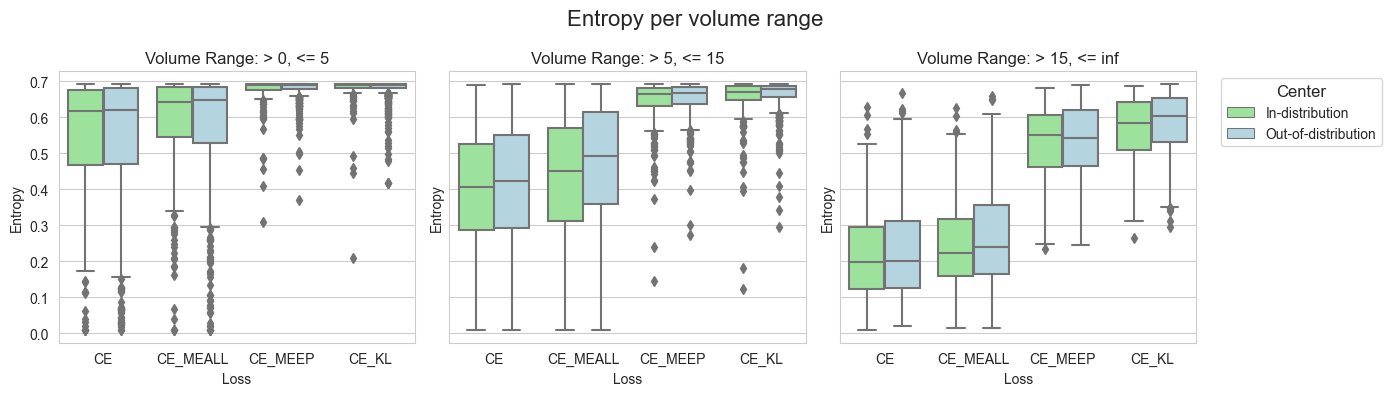

In [20]:
df = entropy_volume_ranges(plot_data, volume_ranges)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import SimpleITK as sitk


def dice_per_volume_range(plot_data,
                          volume_ranges=((0, 5), (5, 15), (15, np.inf))):
    centers_train, runs_to_compare, centers_test, test_splits, losses = plot_data.values()

    rename_centers = {'UtAmSi': 'In-distribution',
                      'UMCL': 'Out-of-distribution'}
    loss_order = ['CE', 'CE_MEALL', 'CE_MEEP', 'CE_KL']

    for tr_center in centers_train:
        plot_data = {}
        for loss in losses:
            plot_data[loss] = {}
            run_name = runs_to_compare[f'{loss} {tr_center}']
            if f'{loss} {tr_center}' not in runs_to_compare.keys():
                print(f'No run for {run_name}.')
                continue
            for ts_center in centers_test:
                plot_data[loss][ts_center] = {
                    f"> {volume_ranges[i][0]}, <= {volume_ranges[i][1]}": []
                    for i in range(len(volume_ranges))
                }
                gt_pths = get_gt_paths(test_splits[ts_center])
                for subj_path in gt_pths:
                    pred_softmax_path = os.path.join(subj_path,
                                                     f'pred_wmh_softmax_{run_name}.nii.gz')
                    gt_path = os.path.join(subj_path,
                                           f'gt_wmh_{run_name}.nii.gz')

                    pred_softmax = sitk.ReadImage(pred_softmax_path)
                    hard_pred = sitk.GetArrayFromImage(pred_softmax).argmax(
                        axis=0)

                    gt = sitk.ReadImage(gt_path)
                    gt = sitk.GetArrayFromImage(gt)

                    cc = sitk.ConnectedComponent(sitk.GetImageFromArray(
                        (hard_pred > 0).astype(np.uint8)))
                    cc = sitk.RelabelComponent(cc)

                    for i in range(1, sitk.GetArrayFromImage(cc).max() + 1):
                        cc_mask_f = sitk.GetArrayFromImage(cc == i).flatten()
                        filt = np.where(cc_mask_f == 1)[0]
                        volume = len(filt) * np.prod(pred_softmax.GetSpacing())
                        sftmx_f = \
                            sitk.GetArrayFromImage(pred_softmax).flatten()[filt]
                        hard_f = hard_pred.flatten()[filt]

                        gt_f = gt.flatten()[filt]

                        dice = dice_score(hard_f, gt_f)

                        for i, (lower, upper) in enumerate(volume_ranges):
                            if lower < volume <= upper:
                                plot_data[loss][ts_center][
                                    f"> {lower}, <= {upper}"].append(dice)
                                break

    # Prepare the data for plotting
    data = []
    for loss in losses:
        for center in centers_test:
            for range_label, dices in plot_data[loss][center].items():
                renamed_center = rename_centers.get(center, center)
                data.extend(
                    [(loss, renamed_center, range_label, dic) for dic in dices])

    df = pd.DataFrame(data, columns=['Loss', 'Center', 'Volume Range', 'Dice'])
    # Create a single plot
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

    # Define the order of centers
    center_order = ['In-distribution', 'Out-of-distribution']

    # Find global min and max for consistent y-axis
    # global_min = df['Entropy'].min()
    # global_max = df['Entropy'].max()

    # Create a boxplot for each volume range
    for i, volume_range in enumerate(df['Volume Range'].unique()):
        ax = axes[i]

        # Filter the DataFrame for the current volume range
        range_df = df[df['Volume Range'] == volume_range]

        # Create boxplots for each loss and center
        sns.boxplot(data=range_df, x='Loss', y='Dice', hue='Center',
                    order=loss_order, hue_order=center_order,
                    palette={'In-distribution': 'lightgreen',
                             'Out-of-distribution': 'lightblue'},
                    ax=ax)

        print(range_df)

        ax.set_title(f'Volume Range: {volume_range}')
        ax.set_xlabel('Loss')
        ax.set_ylabel('Dice')

        # Rotate x-axis labels for better readability
        ax.set_xticklabels(ax.get_xticklabels())

        # Set y-axis limits consistently across subplots
        # ax.set_ylim(global_min, global_max)

        # Add median lines
        for i, artist in enumerate(ax.artists):
            col = artist.get_facecolor()
            artist.set_edgecolor(col)
            artist.set_facecolor('None')

            y = range_df[(range_df['Loss'] == loss_order[i // 2]) &
                         (range_df['Center'] == center_order[i % 2])][
                'Dice'].median()
            ax.hlines(y, *artist.get_xy()[:2], colors=col, linestyles='--',
                      linewidth=2)

        # Only show legend for the last subplot
        if i < 2:
            ax.get_legend().remove()

    #move the legend outside the plot
    plt.legend(title='Center', title_fontsize=12, fontsize=10,
               bbox_to_anchor=(1.05, 1), loc='upper left')

    # Set the overall title for the entire plot
    fig.suptitle('Dice per volume range', fontsize=16)

    # Adjust the layout
    plt.tight_layout()
    plt.show()

# You would call this function with your plot_data dictionary as before

          Loss               Center Volume Range  Dice
0           CE  Out-of-distribution    > 0, <= 5   1.0
1           CE  Out-of-distribution    > 0, <= 5   1.0
2           CE  Out-of-distribution    > 0, <= 5   1.0
3           CE  Out-of-distribution    > 0, <= 5   0.0
4           CE  Out-of-distribution    > 0, <= 5   0.0
...        ...                  ...          ...   ...
9695  CE_MEALL      In-distribution    > 0, <= 5   1.0
9696  CE_MEALL      In-distribution    > 0, <= 5   1.0
9697  CE_MEALL      In-distribution    > 0, <= 5   1.0
9698  CE_MEALL      In-distribution    > 0, <= 5   1.0
9699  CE_MEALL      In-distribution    > 0, <= 5   1.0

[3126 rows x 4 columns]
          Loss               Center Volume Range  Dice
614         CE  Out-of-distribution   > 5, <= 15   1.0
615         CE  Out-of-distribution   > 5, <= 15   1.0
616         CE  Out-of-distribution   > 5, <= 15   0.0
617         CE  Out-of-distribution   > 5, <= 15   1.0
618         CE  Out-of-distribution   > 

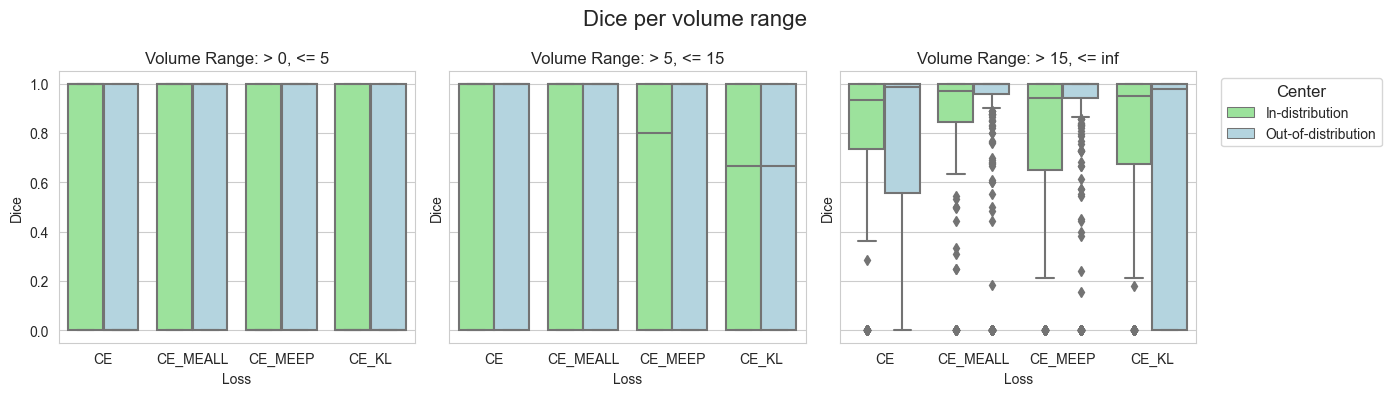

In [28]:
dice_per_volume_range(plot_data, volume_ranges)

In [ ]:
def reliability_plots(plot_data):
    num_bins = 10
    centers_train, runs_to_compare, centers_test, test_splits, losses = plot_data.values()

    for tr_center in centers_train:  # Three plots: one per training center
        plot_data = {}  # Reliability plots
        for loss in losses:  # One subplot per loss
            plot_data[loss] = {}
            run_name = runs_to_compare[f'{loss} {tr_center}']
            if f'{loss} {tr_center}' not in runs_to_compare.keys():
                print(f'No run for {run_name}.')
                continue
            for ts_center in centers_test:  # For each center used for testing
                gt_pths = get_gt_paths(
                    test_splits[ts_center])  # Lst of tst sbj pts
                preds_arr, gts_arr = [], []
                for subj_path in gt_pths:
                    gt_path = os.path.join(subj_path,
                                           f'gt_wmh_{run_name}.nii.gz')
                    pred_softmax_path = os.path.join(
                        subj_path, f'pred_wmh_softmax_{run_name}.nii.gz'
                    )

                    pred_softmax = nib.load(pred_softmax_path).get_fdata()
                    gt = nib.load(gt_path).get_fdata()
                    gt_one_hot = np.eye(2, dtype=np.uint8)[gt.astype(int)]

                    preds_arr = np.concatenate(
                        (preds_arr, pred_softmax[..., 1].flatten())
                    )
                    gts_arr = np.concatenate(
                        (gts_arr, gt_one_hot[..., 1].flatten())
                    )

                emp_probs, pred_probs = calibration_curve(gts_arr, preds_arr,
                                                          n_bins=num_bins)
                plot_data[loss][ts_center] = {
                    'emp_probs': emp_probs,
                    'pred_probs': pred_probs,
                    'ece': get_ece(preds_arr, gts_arr.astype(int))
                }

        fig, axes = plt.subplots(1, len(centers_test), figsize=(13.5, 4.5),
                                 sharey=True)

        [axes[i].plot([0, 1], [0, 1], 'k:', label='Perfectly calibrated') for i
         in range(len(centers_test))]  # Add the perfect calibration line
        for loss, ts_center_data in plot_data.items():
            for i, (ts_center, data) in enumerate(ts_center_data.items()):
                ax = axes[i]

                # Extract data from plot_data
                emp_probs = data['emp_probs']
                pred_probs = data['pred_probs']
                ece = data['ece']

                ax.plot(pred_probs, emp_probs, 'o-',
                        label=f'{loss} - ECE: {ece:.4e}')
                ax.set_xlabel('Predicted probability')
                ax.set_ylabel('Empirical probability')
                ax.set_ylim([-0.05, 1.05])
                ax.legend()

                # Set titles, labels, and other formatting
                ax.set_title(f'Center: {ts_center}')
                ax.set_xlabel('Empirical probability')
                ax.set_ylabel('Predicted probability')

                # Make the subplot square
                ax.set_aspect('equal', 'box')

        for ax in axes[1:]:
            ax.set_ylabel('')

        plt.suptitle(f'Reliability plots using {tr_center} for training')

        # Adjust layout
        plt.tight_layout()

        # Show the plot
        plt.show()

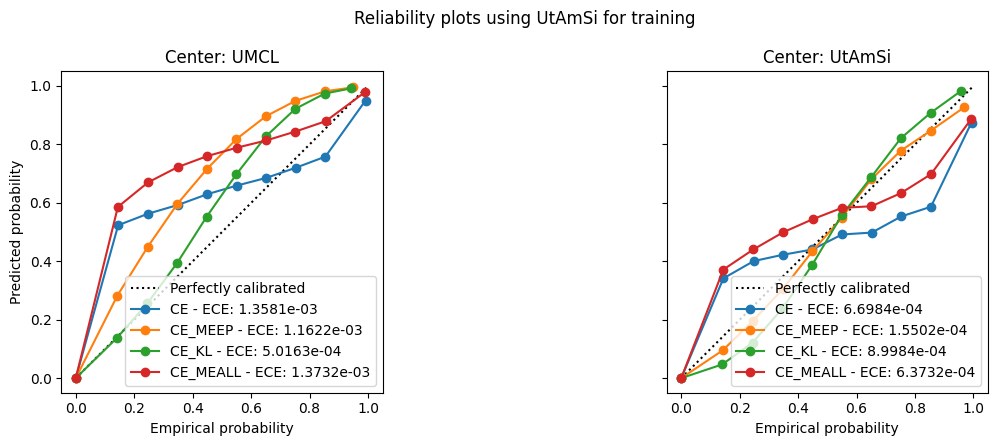

In [7]:
reliability_plots(plot_data)

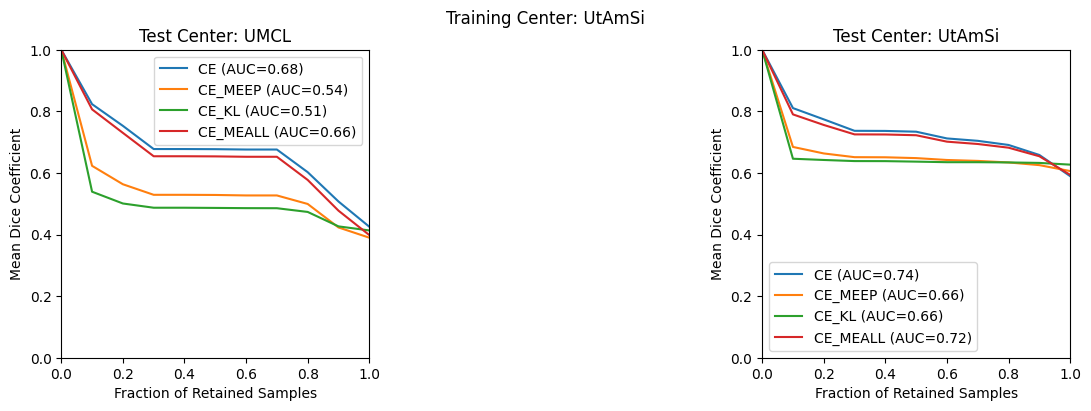

In [6]:
error_retention_curve(plot_data)